In [3]:
import pandas as pd

df = train.copy()

In [4]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["day_of_week"] = df["date"].dt.dayofweek
df["day_of_year"] = df["date"].dt.dayofyear
df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)
df["quarter"] = df["date"].dt.quarter
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

In [5]:
df.head()

,date,store,item,sales,year,month,day,day_of_week,day_of_year,week_of_year,quarter,is_weekend
0,2013-01-01,1,1,13,2013,1,1,1,1,1,1,0
1,2013-01-02,1,1,11,2013,1,2,2,2,1,1,0
2,2013-01-03,1,1,14,2013,1,3,3,3,1,1,0
3,2013-01-04,1,1,13,2013,1,4,4,4,1,1,0
4,2013-01-05,1,1,10,2013,1,5,5,5,1,1,1


In [6]:
df = df.sort_values(["store", "item", "date"])

df["lag_1"] = df.groupby(["store", "item"])["sales"].shift(1)
df["lag_7"] = df.groupby(["store", "item"])["sales"].shift(7)
df["lag_30"] = df.groupby(["store", "item"])["sales"].shift(30)

In [7]:
df.head(40)

,date,store,item,sales,year,month,day,day_of_week,day_of_year,week_of_year,quarter,is_weekend,lag_1,lag_7,lag_30
0,2013-01-01,1,1,13,2013,1,1,1,1,1,1,0,NaN,NaN,NaN
1,2013-01-02,1,1,11,2013,1,2,2,2,1,1,0,13.0,NaN,NaN
2,2013-01-03,1,1,14,2013,1,3,3,3,1,1,0,11.0,NaN,NaN
3,2013-01-04,1,1,13,2013,1,4,4,4,1,1,0,14.0,NaN,NaN
4,2013-01-05,1,1,10,2013,1,5,5,5,1,1,1,13.0,NaN,NaN
5,2013-01-06,1,1,12,2013,1,6,6,6,1,1,1,10.0,NaN,NaN
6,2013-01-07,1,1,10,2013,1,7,0,7,2,1,0,12.0,NaN,NaN
7,2013-01-08,1,1,9,2013,1,8,1,8,2,1,0,10.0,13.0,NaN
8,2013-01-09,1,1,12,2013,1,9,2,9,2,1,0,9.0,11.0,NaN
9,2013-01-10,1,1,9,2013,1,10,3,10,2,1,0,12.0,14.0,NaN


In [8]:
df["rolling_mean_7"] = (
    df.groupby(["store", "item"])["sales"]
      .transform(lambda x: x.shift(1).rolling(7).mean())
)

df["rolling_mean_30"] = (
    df.groupby(["store", "item"])["sales"]
      .transform(lambda x: x.shift(1).rolling(30).mean())
)

In [9]:
df["rolling_std_7"] = (
    df.groupby(["store", "item"])["sales"]
      .transform(lambda x: x.shift(1).rolling(7).std())
)

In [10]:
df.isnull().sum()

date                   0
store                  0
item                   0
sales                  0
year                   0
month                  0
day                    0
day_of_week            0
day_of_year            0
week_of_year           0
quarter                0
is_weekend             0
lag_1                500
lag_7               3500
lag_30             15000
rolling_mean_7      3500
rolling_mean_30    15000
rolling_std_7       3500
dtype: int64

In [12]:
df = df.dropna().reset_index(drop=True)

In [13]:
df.shape

(898000, 18)

In [14]:
df.isnull().sum()

date               0
store              0
item               0
sales              0
year               0
month              0
day                0
day_of_week        0
day_of_year        0
week_of_year       0
quarter            0
is_weekend         0
lag_1              0
lag_7              0
lag_30             0
rolling_mean_7     0
rolling_mean_30    0
rolling_std_7      0
dtype: int64

In [15]:
train_df = df[df["date"] < "2017-01-01"].copy()
test_df = df[df["date"] >= "2017-01-01"].copy()

print(train_df.shape)
print(test_df.shape)

(715500, 18)
(182500, 18)


In [16]:
features = [
    "store",
    "item",
    "year",
    "month",
    "day",
    "day_of_week",
    "day_of_year",
    "week_of_year",
    "quarter",
    "is_weekend",
    "lag_1",
    "lag_7",
    "lag_30",
    "rolling_mean_7",
    "rolling_mean_30",
    "rolling_std_7"
]

target = "sales"

In [17]:
X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

In [18]:
from sklearn.linear_model import LinearRegression

In [19]:
baseline_model = LinearRegression()

In [20]:
baseline_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](16,)","[-0. ,-0. , 0.12,..., 0.48, 0.34,-0.08]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](16,)","['store','item','year',...,'rolling_mean_7','rolling_mean_30', 'rolling_std_7']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-274.2
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,16
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,16


In [21]:
y_pred = baseline_model.predict(X_test)

In [22]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
import numpy as np

In [23]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 7.069975145168598
RMSE: 9.23565673608937
R²  : 0.9143228601270323


In [24]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

results["Residual"] = results["Actual"] - results["Predicted"]

results.head()

,Actual,Predicted,Residual
1431,19,23.374539,-4.374539
1432,15,11.285887,3.714113
1433,10,12.855778,-2.855778
1434,16,16.125148,-0.125148
1435,14,19.670307,-5.670307


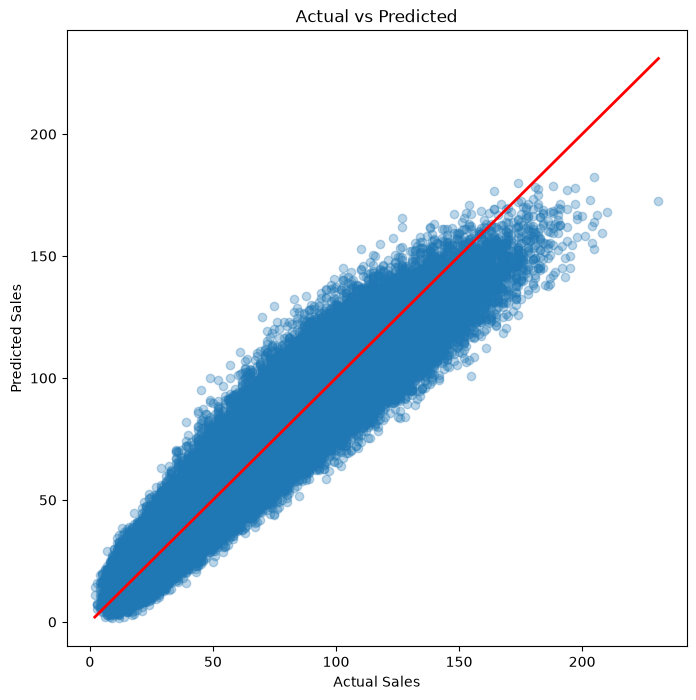

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted")
plt.show()

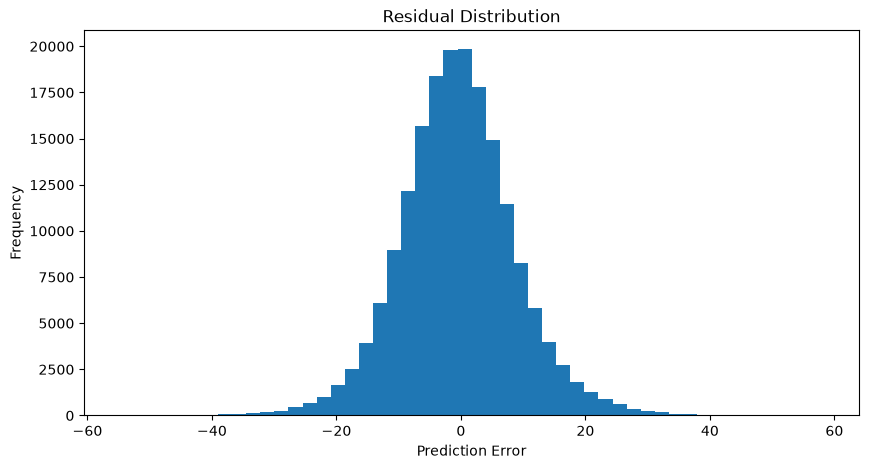

In [26]:
plt.figure(figsize=(10,5))
plt.hist(results["Residual"], bins=50)
plt.title("Residual Distribution")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.show()

In [27]:
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": baseline_model.coef_
})

coef_df.sort_values("Coefficient", ascending=False)

,Feature,Coefficient
3,month,17.621734
5,day_of_week,2.656343
8,quarter,0.893552
4,day,0.586610
13,rolling_mean_7,0.480111
14,rolling_mean_30,0.340735
11,lag_7,0.160683
2,year,0.124223
10,lag_1,0.014223
12,lag_30,0.010867


In [28]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)

In [29]:
xgb_model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [30]:
y_pred_xgb = xgb_model.predict(X_test)

In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE :", mean_absolute_error(y_test, y_pred_xgb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))
print("R²  :", r2_score(y_test, y_pred_xgb))

MAE : 6.093895435333252
RMSE: 7.918365242755336
R²  : 0.9370203018188477


In [32]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

importance = importance.sort_values("Importance", ascending=False)

print(importance)

            Feature  Importance
13   rolling_mean_7    0.385031
11            lag_7    0.316474
14  rolling_mean_30    0.124943
9        is_weekend    0.068058
5       day_of_week    0.057179
10            lag_1    0.016761
3             month    0.008430
8           quarter    0.006494
7      week_of_year    0.005340
6       day_of_year    0.003379
4               day    0.002923
12           lag_30    0.002132
15    rolling_std_7    0.001257
2              year    0.000627
1              item    0.000501
0             store    0.000471


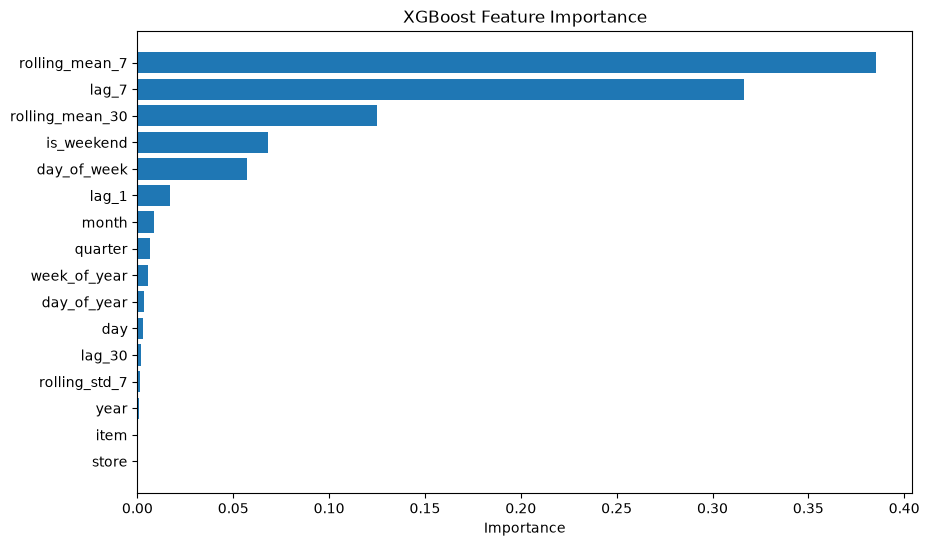

In [33]:
plt.figure(figsize=(10,6))
plt.barh(importance["Feature"], importance["Importance"])
plt.gca().invert_yaxis()
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.show()

In [34]:
import joblib

joblib.dump(xgb_model, "../models/xgboost_model.pkl")

['../models/xgboost_model.pkl']

In [35]:
loaded_model = joblib.load("../models/xgboost_model.pkl")